In [3]:
# import required libraries for model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
# load dataset(csv) file
df = pd.read_csv("usa_rain_prediction_dataset_2024_2025.csv")

print("Dataset Shape:", df.shape)
print(df.head())


Dataset Shape: (73100, 9)
         Date  Location  Temperature   Humidity  Wind Speed  Precipitation  \
0  2024-01-01  New York    87.524795  75.655455   28.379506       0.000000   
1  2024-01-02  New York    83.259325  28.712617   12.436433       0.526995   
2  2024-01-03  New York    80.943050  64.740043   14.184831       0.916884   
3  2024-01-04  New York    78.097552  59.738984   19.444029       0.094134   
4  2024-01-05  New York    37.059963  34.766784    3.689661       1.361272   

   Cloud Cover     Pressure  Rain Tomorrow  
0    69.617966  1026.030278              0  
1    41.606048   995.962065              0  
2    77.364763   980.796739              1  
3    52.541196   979.012163              0  
4    85.584000  1031.790859              0  


In [5]:
# basic info
df.info()
df.describe()

#check missing values
print(df.isnull().sum())

# Ensure Date column is processed and dropped if it exists
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df['year'] = df['Date'].dt.year
    df['month'] = df['Date'].dt.month
    df['day'] = df['Date'].dt.day
    df.drop("Date", axis=1, inplace=True)

le = LabelEncoder()

# encoding for location column
if df['Location'].dtype == 'object':
    df['Location'] = le.fit_transform(df['Location'])

X = df.drop("Rain Tomorrow", axis=1)
y = df["Rain Tomorrow"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           73100 non-null  object 
 1   Location       73100 non-null  object 
 2   Temperature    73100 non-null  float64
 3   Humidity       73100 non-null  float64
 4   Wind Speed     73100 non-null  float64
 5   Precipitation  73100 non-null  float64
 6   Cloud Cover    73100 non-null  float64
 7   Pressure       73100 non-null  float64
 8   Rain Tomorrow  73100 non-null  int64  
dtypes: float64(6), int64(1), object(2)
memory usage: 5.0+ MB
Date             0
Location         0
Temperature      0
Humidity         0
Wind Speed       0
Precipitation    0
Cloud Cover      0
Pressure         0
Rain Tomorrow    0
dtype: int64


In [6]:
# train & test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# use appropriate scaller
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# use model
model = LogisticRegression()


model.fit(X_train, y_train)

LogisticRegression()

In [7]:
y_pred = model.predict(X_test)

# accuracy for project
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9090287277701778

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.97      0.94     11369
           1       0.86      0.71      0.78      3251

    accuracy                           0.91     14620
   macro avg       0.89      0.84      0.86     14620
weighted avg       0.91      0.91      0.91     14620



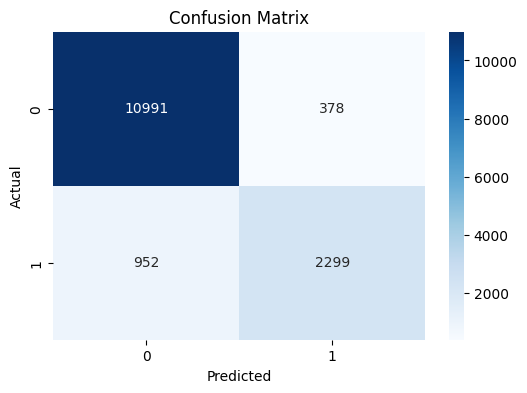

In [8]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

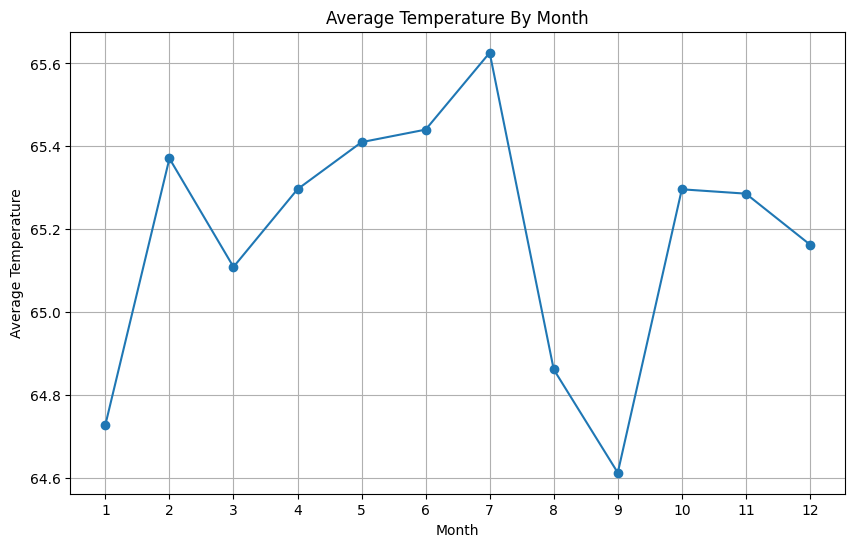

In [10]:
import matplotlib.pyplot as plt

# Calculate the average temperature by month
average_temp_by_month = df.groupby('month')['Temperature'].mean()

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(average_temp_by_month.index, average_temp_by_month.values, marker='o')

plt.xlabel("Month")
plt.ylabel("Average Temperature")
plt.title("Average Temperature By Month")
plt.grid(True)
plt.xticks(range(1, 13)) # Ensure all months are shown on x-axis
plt.show()